# Fraud Detection — Explainability
### IEEE-CIS Fraud Detection Dataset
This notebook uses SHAP values to explain why XGBoost model flags certain transactions as fraud. Finds out which features matter most, and why?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [3]:
xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=8,
    learning_rate=0.4,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [4]:
explainer = shap.TreeExplainer(xgb_model)

X_sample = X_test.sample(1000, random_state=42)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (1000, 431)


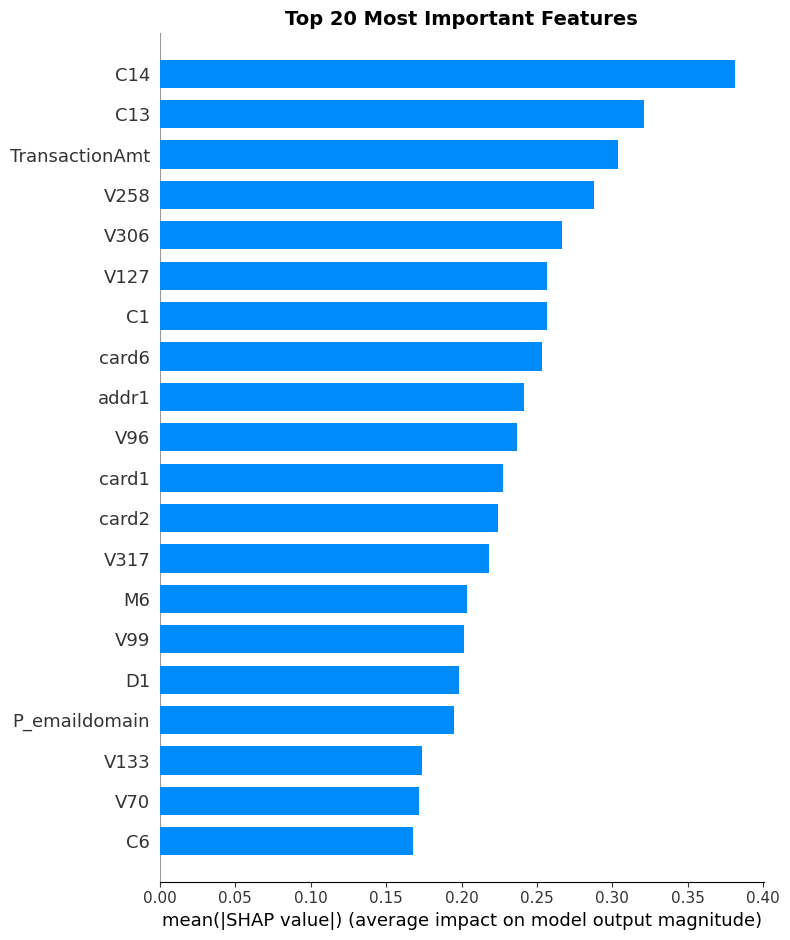

In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=20, show=False)
plt.title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

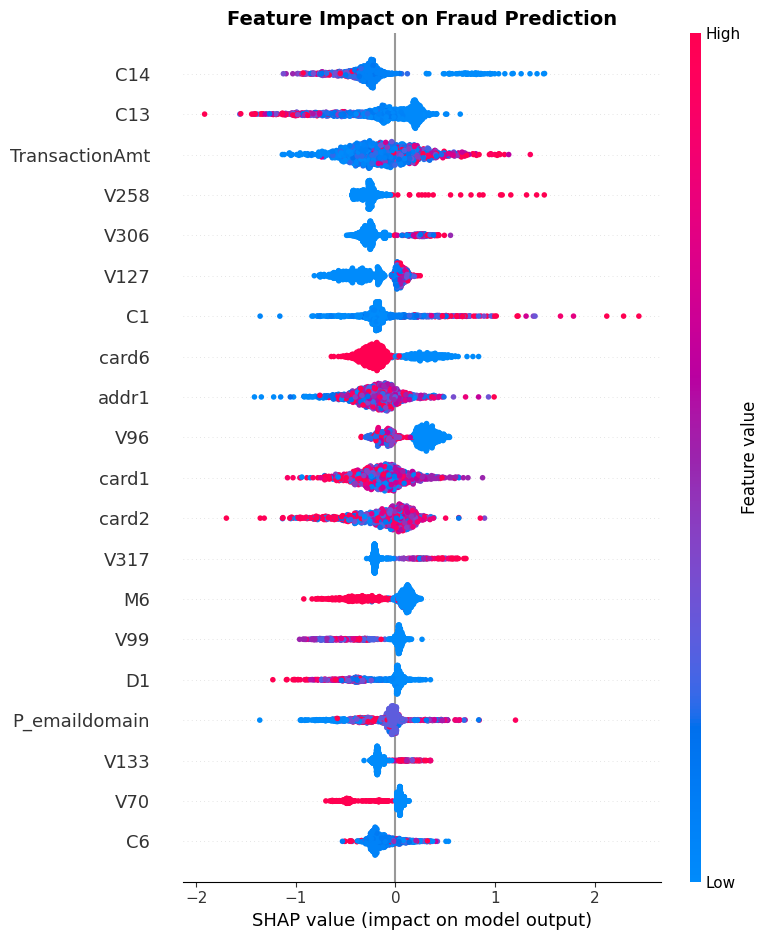

In [6]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.title('Feature Impact on Fraud Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_dot_plot.png', dpi=150, bbox_inches='tight')
plt.show()

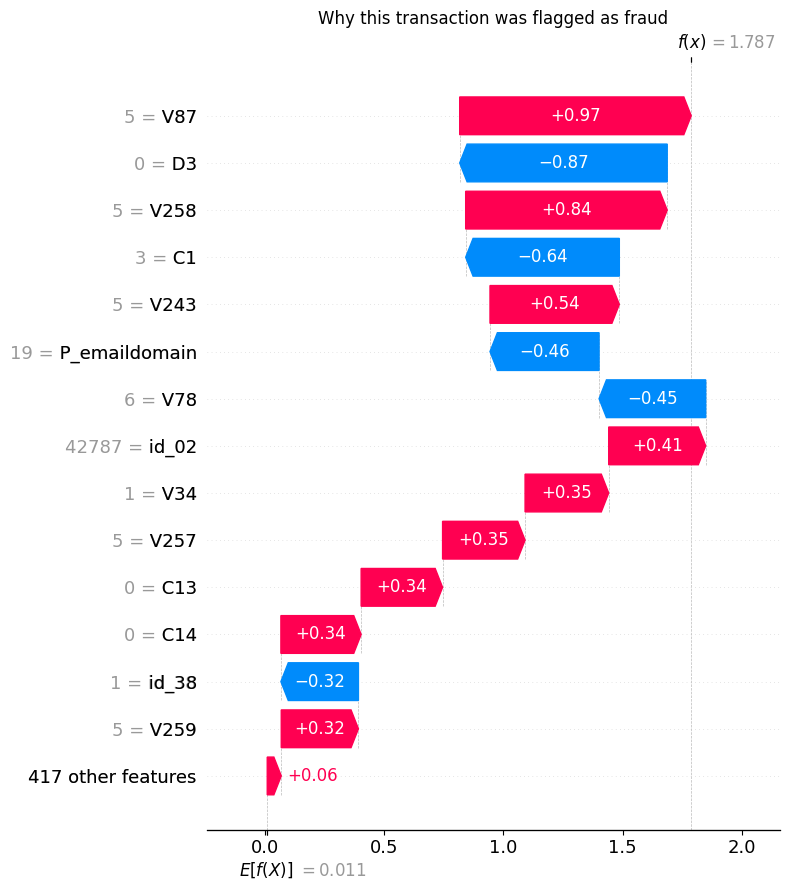

In [7]:
# Find a transaction the model got right — predicted fraud and actually was fraud
fraud_indices = X_sample[X_sample.index.isin(
    y_test[y_test == 1].index)].index[:1]

fraud_row = X_sample.loc[fraud_indices]
fraud_idx = X_sample.index.get_loc(fraud_indices[0])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[fraud_idx],
        base_values=explainer.expected_value,
        data=fraud_row.values[0],
        feature_names=X_sample.columns.tolist()
    ),
    max_display=15,
    show=False
)
plt.title('Why this transaction was flagged as fraud', fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()